# DSA — Comparativa de calendarios (testing)

Prueba **mínima** (5 ventanas) que evalúa el modelo DSA sobre **el mismo dataset** (`consumo_bd.csv`) en tres configuraciones de calendario, para comparar su rendimiento:

| # | Escenario | `SERIES_WEEK_DAYS` | `WEEKEND_FILL` |
|---|-----------|--------------------|----------------|
| (a) | Calendario completo (7 días), DSA como siempre | 7 | — |
| (b) | Calendario de negocio (5 días): se eliminan los fines de semana y se rellenan con la **media de la semana anterior** (5 días hábiles) | 5 | `"mean"` |
| (c) | Calendario de negocio (5 días): se eliminan los fines de semana y se rellenan por **interpolación lineal** (viernes→lunes) | 5 | `"interp"` |

Cada escenario usa las mismas funciones que `dsa_univariate.ipynb`. Salida: **métricas desagregadas** (punto de partida × horizonte: nowcast M, M+1, M+2, M+3) y **gráficos de predicción**.

In [1]:
# ============================================================
# (1) Instalación de paquetes (sólo si faltan; en Colab los instala)
# ============================================================
if (!requireNamespace("dsa", quietly = TRUE)) {
  system("apt-get update -qq")
  system("apt-get install -y default-jdk r-cran-rjava")
  system("R CMD javareconf")
  install.packages(c("dsa","xts","zoo","lubridate","dplyr","timeDate","ggplot2","reshape2"),
                   repos = "https://cloud.r-project.org")
}

In [2]:
# ============================================================
# (2) Librerías
# ============================================================
suppressWarnings(suppressMessages({
  library(dplyr); library(xts); library(zoo); library(lubridate)
  library(dsa);   library(timeDate); library(ggplot2); library(reshape2)
}))
options(warn = 1)

In [3]:
# ============================================================
# (3) Transformación y covariables de calendario
# ============================================================
# ============================================================
# Transformation
# ============================================================

### TBC: Choose between "level" / "log" / "log1p"
TRANSFORMATION <- "log"

# Funciones de transformación y reversión
transform_level <- function(x, transformation = c("log", "log1p", "level")) {
  transformation <- match.arg(transformation)

  if (transformation == "log") {
    return(log(x))
  }

  if (transformation == "log1p") {
    return(log1p(x))
  }

  if (transformation == "level") {
    return(x)
  }
}

inverse_transform <- function(x, transformation = c("log", "log1p", "level")) {
  transformation <- match.arg(transformation)

  if (transformation == "log") {
    return(exp(x))
  }

  if (transformation == "log1p") {
    return(expm1(x))
  }

  if (transformation == "level") {
    return(x)
  }
}

# ============================================================
# Calendar covariates y calendario de la serie
# ============================================================

add_calendar_covariates <- function(df, date_col = "timestamp") {
  df <- df %>%
    mutate(
      timestamp = as.Date(.data[[date_col]]),
      dow = wday(timestamp, week_start = 1) - 1,
      month = month(timestamp),
      day = day(timestamp),
      week = isoweek(timestamp),
      is_weekend = as.integer(dow >= 5)
    )

  years <- unique(year(df$timestamp))

  fixed_holidays <- do.call(c, lapply(years, function(y) {
    as.Date(c(
      paste0(y, "-01-01"), paste0(y, "-01-06"), paste0(y, "-05-01"),
      paste0(y, "-05-02"), paste0(y, "-06-24"), paste0(y, "-08-15"),
      paste0(y, "-10-12"), paste0(y, "-11-01"), paste0(y, "-12-06"),
      paste0(y, "-12-08"), paste0(y, "-12-25"), paste0(y, "-12-31")
    ))
  }))

  easter_sundays <- as.Date(Easter(years))
  easter_related <- do.call(c, lapply(easter_sundays, function(e) {
    as.Date(e + days(-7:1))
  }))

  holidays_all <- unique(c(fixed_holidays, easter_related))

  df <- df %>%
    mutate(
      is_holiday = as.integer(timestamp %in% holidays_all),
      is_pre_holiday = as.integer((timestamp + days(1)) %in% holidays_all),
      is_post_holiday = as.integer((timestamp - days(1)) %in% holidays_all),
      is_bridge_day = as.integer(
        (is_weekend == 0 & is_holiday == 0) & (is_pre_holiday == 1 | is_post_holiday == 1)
      ),
      is_easter_week = as.integer(timestamp %in% easter_related)
    )

  return(df)
}

In [4]:
# ============================================================
# (4) Funciones del experimento (idénticas a dsa_univariate.ipynb)
# ============================================================
# ============================================================
# DEFINICIÓN DE FUNCIONES (vendimias / growing-window forecast)
# ============================================================


# ---- Secuencia de fechas respetando el calendario elegido ----
date_sequence_by_week_days <- function(start_date, end_date, week_days = SERIES_WEEK_DAYS) {
  start_date <- as.Date(start_date); end_date <- as.Date(end_date)
  if (is.na(start_date) || is.na(end_date) || start_date > end_date) return(as.Date(character()))
  idx <- seq(start_date, end_date, by = "1 day")
  if (week_days == 5) {
    idx <- idx[as.integer(format(idx, "%u")) <= 5]
  } else if (week_days != 7) {
    stop("week_days debe ser 5 (lunes-viernes) o 7 (calendario completo).")
  }
  as.Date(idx)
}

# ---- ¿Contiene el rango [a, b] algún 29 de febrero? (Tarea 2) ----
range_has_leap_day <- function(a, b) {
  a <- as.Date(a); b <- as.Date(b)
  if (is.na(a) || is.na(b) || a > b) return(FALSE)
  d <- seq(a, b, by = "1 day")
  any(format(d, "%m-%d") == "02-29")
}

# ---- n-ésimo día hábil del mes (para cortes en calendario de negocio) ----
nth_business_day_of_month <- function(month_start, n) {
  month_start <- as.Date(month_start)
  days <- seq(lubridate::floor_date(month_start, "month"),
              lubridate::ceiling_date(month_start, "month") - lubridate::days(1), by = "day")
  bdays <- days[as.integer(format(days, "%u")) <= 5]
  if (n > length(bdays)) return(as.Date(NA))
  bdays[n]
}

# ---- Agregación de un vector de niveles ----
aggregate_level <- function(x, agg = "sum", empty_value = NA_real_) {
  x <- as.numeric(x); x <- x[is.finite(x)]
  if (length(x) == 0) return(empty_value)
  if (agg == "sum")  return(sum(x))
  if (agg == "mean") return(mean(x))
  stop("agg debe ser 'sum' o 'mean'.")
}

# ============================================================
# Relleno de fines de semana para el calendario de negocio (week_days = 5)
# ------------------------------------------------------------
# El DSA necesita una serie diaria completa de 7 días. En el modo de negocio
# rellenamos sábados y domingos SIN usar NaN/0, eligiendo el modo:
#   "mean"   : media de los 5 días hábiles (lun-vie) inmediatamente anteriores
#              (apropiado con fuerte estacionariedad diaria)
#   "interp" : interpolación lineal entre el último viernes y el lunes siguiente
#              (apropiado con fuerte tendencia)
# Trabaja sobre la serie en NIVELES; el caller recalcula la serie transformada.
# ============================================================
fill_weekends <- function(df, date_col, level_col, mode = c("mean", "interp")) {
  mode <- match.arg(mode)
  df <- df %>% arrange(.data[[date_col]])
  dts <- as.Date(df[[date_col]])
  wd  <- as.integer(format(dts, "%u"))          # 1=Lun ... 7=Dom
  is_wknd <- wd >= 6
  lvl <- as.numeric(df[[level_col]])

  if (mode == "interp") {
    lvl_na <- lvl; lvl_na[is_wknd] <- NA
    lvl_filled <- zoo::na.approx(lvl_na, x = as.numeric(dts), na.rm = FALSE)
  } else {                                       # "mean"
    bus_idx <- which(!is_wknd)
    lvl_filled <- lvl
    for (i in which(is_wknd)) {
      prev_bus <- bus_idx[bus_idx < i]
      if (length(prev_bus) >= 1) {
        lvl_filled[i] <- mean(lvl[tail(prev_bus, 5)], na.rm = TRUE)   # 5 días hábiles previos
      } else {
        nxt_bus <- bus_idx[bus_idx > i]
        lvl_filled[i] <- if (length(nxt_bus)) mean(lvl[head(nxt_bus, 5)], na.rm = TRUE) else NA_real_
      }
    }
  }
  # Cierra cualquier hueco restante (p.ej. festivos no hábiles) de forma robusta
  lvl_filled <- zoo::na.approx(lvl_filled, x = as.numeric(dts), na.rm = FALSE)
  lvl_filled <- zoo::na.locf(lvl_filled, na.rm = FALSE)
  lvl_filled <- zoo::na.locf(lvl_filled, fromLast = TRUE, na.rm = FALSE)
  df[[level_col]] <- lvl_filled
  df
}

# ============================================================
# Agregación de resultados diarios a semanal/mensual
# (Diario PROC -> Diario niveles -> Agregado niveles -> Agregado PROC)
# Marca además los periodos que contienen un 29 de febrero (Tarea 2).
# ============================================================
build_aggregate_eval <- function(daily_eval_df, context_df,
                                 date_col = DATE_COLUMN, level_target_col = LEVEL_TARGET_COLUMN,
                                 unit = c("week", "month"), week_days = SERIES_WEEK_DAYS,
                                 aggregate_fun = AGGREGATE_FUN, transformation = TRANSFORMATION) {
  unit <- match.arg(unit)
  if (is.null(daily_eval_df) || nrow(daily_eval_df) == 0) return(data.frame())

  context_levels <- context_df %>%
    transmute(.fecha = as.Date(.data[[date_col]]), .level = as.numeric(.data[[level_target_col]])) %>%
    filter(!is.na(.fecha))
  if (week_days == 5) context_levels <- context_levels %>% filter(as.integer(format(.fecha, "%u")) <= 5)

  daily_aug <- daily_eval_df %>% mutate(fecha = as.Date(fecha), cutoff_date = as.Date(cutoff_date))
  if (!("id_ventana" %in% colnames(daily_aug)))
    daily_aug <- daily_aug %>% mutate(id_ventana = paste("Corte", cutoff_date))

  if (unit == "week") {
    daily_aug <- daily_aug %>% mutate(period_start = floor_date(fecha, "week", week_start = 1),
                                      period_end = period_start + days(6))
  } else {
    daily_aug <- daily_aug %>% mutate(period_start = floor_date(fecha, "month"),
                                      period_end = ceiling_date(period_start, "month") - days(1))
  }

  grouped <- daily_aug %>%
    group_by(id_ventana, cutoff_date, cutoff_day, week_no, period_start, period_end) %>% group_split()

  rows <- lapply(grouped, function(g) {
    g <- g %>% arrange(fecha)
    cutoff_date <- as.Date(g$cutoff_date[1]); period_start <- as.Date(g$period_start[1]); period_end <- as.Date(g$period_end[1])
    period_dates <- date_sequence_by_week_days(period_start, period_end, week_days)

    observed_full <- context_levels %>% filter(.fecha %in% period_dates)
    observed_partial <- observed_full %>% filter(.fecha <= cutoff_date)

    available_dates <- unique(observed_full$.fecha[is.finite(observed_full$.level)])
    has_full_observed_period <- length(period_dates) > 0 && all(period_dates %in% available_dates)

    forecast_future_values <- as.numeric(g$yhat_level)
    observed_partial_values <- as.numeric(observed_partial$.level)

    real_level <- if (has_full_observed_period) aggregate_level(observed_full$.level, aggregate_fun) else NA_real_
    pred_level <- aggregate_level(c(observed_partial_values, forecast_future_values), aggregate_fun, empty_value = NA_real_)

    real_proc <- transform_level(real_level, transformation)
    pred_proc <- transform_level(pred_level, transformation)
    proc_error <- pred_proc - real_proc

    period_offset <- if (unit == "month") {
      (year(period_start) - year(cutoff_date)) * 12 + month(period_start) - month(cutoff_date)
    } else {
      as.integer(as.numeric(period_start - floor_date(cutoff_date, "week", week_start = 1)) / 7)
    }

    data.frame(
      id_ventana = g$id_ventana[1], cutoff_date = cutoff_date, cutoff_day = g$cutoff_day[1],
      week_no = g$week_no[1], unit = unit, period_start = period_start, period_end = period_end,
      period_offset = period_offset,
      observed_partial_level = aggregate_level(observed_partial_values, aggregate_fun, empty_value = 0),
      forecast_future_level = aggregate_level(forecast_future_values, aggregate_fun, empty_value = NA_real_),
      real_level = real_level, pred_level = pred_level, real_proc = real_proc, pred_proc = pred_proc,
      proc_error = proc_error, error_pp = 100 * proc_error, abs_error_pp = abs(100 * proc_error),
      observed_partial_n = sum(is.finite(observed_partial_values)), forecast_n = sum(is.finite(forecast_future_values)),
      observed_full_n = sum(is.finite(observed_full$.level)), expected_n = length(period_dates),
      has_full_observed_period = has_full_observed_period,
      has_leap_day = range_has_leap_day(period_start, period_end)   # Tarea 2
    )
  })
  do.call(rbind, rows) %>% arrange(cutoff_date, period_start)
}

# ============================================================
# Predicción en vendimias (growing window)
#   week_days = 7 : calendario completo, dsa() estándar
#   week_days = 5 : calendario de negocio. Se ajusta dsa() sobre un calendario
#                   completo de 7 días con los fines de semana RELLENADOS según
#                   weekend_fill ("mean"/"interp"), y se evalúa sólo en días hábiles.
# ============================================================
run_growing_daily_forecast <- function(context_df, target_col, date_col = "timestamp",
                                        train_history_start, forecast_start_date, last_cutoff_date,
                                        cutoff_days, next_full_months = 3, week_days = 7,
                                        weekend_fill = "mean", level_target_col = "target",
                                        n_forecast_windows = NULL, aggregate_fun = "sum",
                                        transformation = "log") {

  context_df[[date_col]] <- as.Date(context_df[[date_col]])
  train_history_start <- as.Date(train_history_start); forecast_start_date <- as.Date(forecast_start_date)
  last_cutoff_date <- as.Date(last_cutoff_date)
  if (!(target_col %in% colnames(context_df))) stop(paste("No existe target_col:", target_col))
  if (!(level_target_col %in% colnames(context_df))) stop(paste("No existe level_target_col:", level_target_col))

  keep_business <- (week_days == 5)   # evaluación / cortes sólo en días hábiles

  # ---- Serie de AJUSTE: siempre un calendario completo de 7 días ----
  context_fit <- context_df %>% arrange(.data[[date_col]])
  context_fit[[date_col]] <- as.Date(context_fit[[date_col]])

  if (week_days == 5) {
    # Calendario diario completo + relleno de fines de semana (sin NaN/0)
    full_dates <- seq(min(context_fit[[date_col]]), max(context_fit[[date_col]]), by = "day")
    base_df <- setNames(data.frame(full_dates), date_col)
    context_fit <- dplyr::left_join(base_df, context_fit[, c(date_col, level_target_col)], by = date_col)
    context_fit <- fill_weekends(context_fit, date_col, level_target_col, weekend_fill)
    context_fit[[target_col]] <- transform_level(context_fit[[level_target_col]], transformation)
  }
  context_fit <- add_calendar_covariates(context_fit, date_col = date_col)

  # context completo (valores reales observados para la evaluación)
  context_eval <- context_df %>% arrange(.data[[date_col]])

  max_obs_date <- max(context_fit[[date_col]], na.rm = TRUE)
  effective_last_cutoff <- min(last_cutoff_date, max_obs_date)

  calendar_regressors <- setdiff(colnames(context_fit), unique(c(date_col, target_col, level_target_col)))
  calendar_regressors <- calendar_regressors[sapply(context_fit[, calendar_regressors, drop = FALSE], is.numeric)]

  sequence_months <- seq(floor_date(forecast_start_date, "month"), floor_date(effective_last_cutoff, "month"), by = "1 month")

  cutoff_dates <- as.Date(character()); cutoff_nominal <- integer(); cutoff_weekno <- integer()
  for (m in sequence_months) {
    m_date <- as.Date(m)
    for (j in seq_along(cutoff_days)) {
      d <- cutoff_days[j]
      c_date <- if (week_days == 5) nth_business_day_of_month(m_date, d) else m_date + days(d - 1)
      if (!is.na(c_date) && c_date >= forecast_start_date && c_date <= effective_last_cutoff) {
        cutoff_dates <- c(cutoff_dates, c_date); cutoff_nominal <- c(cutoff_nominal, d); cutoff_weekno <- c(cutoff_weekno, j)
      }
    }
  }
  ord <- order(cutoff_dates)
  cutoff_dates <- cutoff_dates[ord]; cutoff_nominal <- cutoff_nominal[ord]; cutoff_weekno <- cutoff_weekno[ord]
  if (!is.null(n_forecast_windows)) {
    keep <- seq_len(min(n_forecast_windows, length(cutoff_dates)))
    cutoff_dates <- cutoff_dates[keep]; cutoff_nominal <- cutoff_nominal[keep]; cutoff_weekno <- cutoff_weekno[keep]
  }

  daily_rows <- list(); cutoff_rows <- list()

  for (i in seq_along(cutoff_dates)) {
    cutoff_date <- cutoff_dates[i]; nominal_d <- cutoff_nominal[i]; week_no <- cutoff_weekno[i]
    forecast_end <- ceiling_date(floor_date(cutoff_date, "month") + months(next_full_months), "month") - days(1)

    # Horizonte sobre calendario completo (excluye 29-feb del horizonte; la serie NO se altera)
    horizon_index <- date_sequence_by_week_days(cutoff_date + days(1), forecast_end, 7)
    horizon_index <- horizon_index[!(format(horizon_index, "%m-%d") == "02-29")]
    if (length(horizon_index) == 0) next

    train_df <- context_fit %>% filter(.data[[date_col]] >= train_history_start, .data[[date_col]] <= cutoff_date)
    if (nrow(train_df) == 0) next

    future_df <- add_calendar_covariates(setNames(data.frame(horizon_index), date_col), date_col = date_col)
    y_train_xts <- xts(as.numeric(train_df[[target_col]]), order.by = train_df[[date_col]])

    reg_train_xts <- xts(train_df[, calendar_regressors, drop = FALSE], order.by = train_df[[date_col]])
    reg_test_xts  <- xts(future_df[, calendar_regressors, drop = FALSE], order.by = horizon_index)
    reg_train <- multi_xts2ts(reg_train_xts); reg_test <- multi_xts2ts(reg_test_xts)
    valid_cols <- apply(reg_train, 2, var, na.rm = TRUE) > 0
    reg_train <- reg_train[, valid_cols, drop = FALSE]; reg_test <- reg_test[, valid_cols, drop = FALSE]
    freq_train <- frequency(reg_train)
    tsp(reg_test) <- c(end(reg_train)[1] + 1 / freq_train, end(reg_train)[1] + length(horizon_index) / freq_train, freq_train)

    fit <- dsa(y_train_xts, regressor = reg_train, forecast_regressor = reg_test, h = length(horizon_index),
               automodel = "reduced", ic = "bic", include.constant = TRUE, progress_bar = FALSE)
    full_forecast <- get_original(fit, forecast = TRUE)
    pred_all <- as.numeric(tail(full_forecast, length(horizon_index)))

    df_all <- data.frame(fecha = horizon_index, yhat = pred_all)
    if (keep_business) df_all <- df_all[as.integer(format(df_all$fecha, "%u")) <= 5, , drop = FALSE]
    pred_proc_values <- df_all$yhat; fcst_dates <- df_all$fecha

    pred_level_values <- inverse_transform(pred_proc_values, transformation)
    test_actuals <- context_eval[, c(date_col, target_col, level_target_col)]
    names(test_actuals) <- c("fecha", "y_true_proc", "y_true_level")

    fcst_daily <- data.frame(
      fecha = fcst_dates, yhat_proc = pred_proc_values, yhat_level = pred_level_values,
      cutoff_date = cutoff_date, cutoff_day = nominal_d, week_no = week_no,
      train_start = min(train_df[[date_col]]), train_end = max(train_df[[date_col]]),
      forecast_start = min(fcst_dates), forecast_end = forecast_end,
      step = seq_along(fcst_dates), id_ventana = paste("Corte", cutoff_date)
    ) %>% left_join(test_actuals, by = "fecha") %>%
      mutate(yhat = yhat_proc, y_true = y_true_proc,
             daily_proc_error = yhat_proc - y_true_proc, daily_error_pp = 100 * daily_proc_error) %>% arrange(fecha)

    daily_rows[[length(daily_rows) + 1]] <- fcst_daily
    cutoff_rows[[length(cutoff_rows) + 1]] <- data.frame(
      cutoff_date = cutoff_date, cutoff_day = nominal_d, week_no = week_no,
      train_start = min(train_df[[date_col]]), train_end = max(train_df[[date_col]]),
      forecast_start = min(fcst_dates), forecast_end = forecast_end,
      prediction_length = length(fcst_dates), train_rows = nrow(train_df),
      week_days = week_days, weekend_fill = if (week_days == 5) weekend_fill else NA_character_,
      reg_train_freq = frequency(reg_train), reg_test_freq = frequency(reg_test))
  }

  daily_eval_df <- if (length(daily_rows) > 0) do.call(rbind, daily_rows) else data.frame()
  cutoff_summary_df <- if (length(cutoff_rows) > 0) do.call(rbind, cutoff_rows) else data.frame()

  weekly_eval_df <- build_aggregate_eval(daily_eval_df, context_eval, date_col, level_target_col, "week",
                                         week_days, aggregate_fun, transformation)
  monthly_eval_df <- build_aggregate_eval(daily_eval_df, context_eval, date_col, level_target_col, "month",
                                          week_days, aggregate_fun, transformation)

  list(daily_eval = daily_eval_df, weekly_eval = weekly_eval_df, monthly_eval = monthly_eval_df,
       cutoff_summary = cutoff_summary_df, cutoff_dates = cutoff_dates)
}

# ============================================================
# Tablas de métricas DESAGREGADAS por punto de partida (Tarea 4)
# Excluye periodos con 29-feb (Tarea 2) y periodos sin observación completa.
# ============================================================
disaggregated_scores <- function(eval_df, by_offset = TRUE) {
  d <- eval_df %>% filter(has_full_observed_period, !has_leap_day, is.finite(real_proc), is.finite(pred_proc))
  if (nrow(d) == 0) return(data.frame())
  grp <- if (by_offset) c("week_no", "cutoff_day", "period_offset") else c("week_no", "cutoff_day")
  d %>% group_by(across(all_of(grp))) %>%
    summarise(n_periodos = n(), ME_pp = mean(error_pp), MAE_pp = mean(abs_error_pp),
              MedAE_pp = median(abs_error_pp), RMSE_pp = sqrt(mean(error_pp^2)), .groups = "drop") %>%
    arrange(week_no, if (by_offset) period_offset else week_no)
}

In [5]:
# ============================================================
# (5) Configuración común del experimento (PRUEBA MÍNIMA: 5 ventanas)
# ============================================================
TARGET_COLUMN       <- "target_proc"
LEVEL_TARGET_COLUMN <- "target"
DATE_COLUMN         <- "timestamp"
TRANSFORMATION      <- "log"
AGGREGATE_FUN       <- "sum"

TRAIN_HISTORY_START <- "2017-01-01"
FORECAST_START_DATE <- "2022-01-01"
LAST_CUTOFF_DATE    <- "2022-12-31"
NEXT_FULL_MONTHS    <- 3
N_FORECAST_WINDOWS  <- 5          # prueba mínima: sólo 5 ventanas
SERIES_WEEK_DAYS    <- 7          # valor por defecto (cada escenario lo fija)

In [6]:
# ============================================================
# (6) Carga del dato (consumo_bd.csv)
# ============================================================
DATA_CANDIDATES <- c("../../data/consumo_bd.csv", "data/consumo_bd.csv",
                     "consumo_bd.csv", "../data/consumo_bd.csv")
DATA_PATH <- DATA_CANDIDATES[file.exists(DATA_CANDIDATES)][1]
if (is.na(DATA_PATH)) stop("No se encuentra consumo_bd.csv; ajusta DATA_PATH manualmente.")
cat("Leyendo:", DATA_PATH, "\n")

Data <- read.csv(DATA_PATH, skip = 2, header = TRUE, dec = ",", stringsAsFactors = FALSE)
Data$timestamp   <- as.Date(Data$timestamp, format = "%d/%m/%Y")
Data$target      <- as.numeric(Data$target)
Data             <- Data[, c("timestamp", "target")]
Data$target_proc <- transform_level(Data$target, TRANSFORMATION)
Data <- add_calendar_covariates(Data, "timestamp") %>% arrange(timestamp) %>% na.omit()
cat("Filas:", nrow(Data), " rango:", format(min(Data$timestamp)), "a", format(max(Data$timestamp)), "\n")

Leyendo: ../../data/consumo_bd.csv 


Filas: 3287  rango: 2017-01-01 a 2025-12-31 


In [7]:
# ============================================================
# (7) Utilidades: ejecutar escenario, métricas desagregadas y gráficos
# ============================================================
run_scenario <- function(week_days, weekend_fill) {
  cutoff_days <- if (week_days == 5) c(5, 10, 15, 20) else c(7, 14, 21, 28)
  run_growing_daily_forecast(
    context_df = Data, target_col = TARGET_COLUMN, date_col = DATE_COLUMN,
    train_history_start = TRAIN_HISTORY_START, forecast_start_date = FORECAST_START_DATE,
    last_cutoff_date = LAST_CUTOFF_DATE, cutoff_days = cutoff_days,
    next_full_months = NEXT_FULL_MONTHS, week_days = week_days,
    weekend_fill = weekend_fill, level_target_col = LEVEL_TARGET_COLUMN,
    n_forecast_windows = N_FORECAST_WINDOWS, aggregate_fun = AGGREGATE_FUN,
    transformation = TRANSFORMATION)
}

horizon_labels <- c("Nowcast (M)", paste0("Forecast (M+", seq_len(NEXT_FULL_MONTHS), ")"))

score_monthly <- function(res) {
  res$monthly_eval %>%
    filter(has_full_observed_period, !has_leap_day, is.finite(real_proc), is.finite(pred_proc),
           period_offset >= 0, period_offset <= NEXT_FULL_MONTHS) %>%
    mutate(Horizonte = factor(horizon_labels[period_offset + 1], levels = horizon_labels)) %>%
    group_by(week_no, cutoff_day, period_offset, Horizonte) %>%
    summarise(n = n(), ME_pp = mean(error_pp), MAE_pp = mean(abs_error_pp),
              MedAE_pp = median(abs_error_pp), RMSE_pp = sqrt(mean(error_pp^2)), .groups = "drop") %>%
    arrange(week_no, period_offset)
}

# Gráfico de predicción diaria (forecast vs real) por ventana de corte
plot_daily <- function(res, titulo) {
  d <- res$daily_eval %>% mutate(fecha = as.Date(fecha))
  ggplot(d, aes(fecha)) +
    geom_line(aes(y = y_true_proc, color = "Real"), linewidth = 0.7) +
    geom_line(aes(y = yhat_proc, color = "Forecast"), linetype = "dashed", linewidth = 0.7) +
    facet_wrap(~ id_ventana, scales = "free", ncol = 2) +
    theme_minimal(base_size = 10) +
    scale_color_manual(values = c("Real" = "black", "Forecast" = "royalblue")) +
    labs(title = titulo, subtitle = "Predicción diaria (escala log) por ventana de corte",
         x = "Fecha", y = "Serie (log)", color = "Serie") +
    theme(legend.position = "bottom")
}

# Gráfico mensual acumulado (real vs forecast) por punto de partida
plot_monthly <- function(res, titulo) {
  d <- res$monthly_eval %>%
    filter(has_full_observed_period, !has_leap_day, is.finite(real_proc), is.finite(pred_proc)) %>%
    mutate(Escenario = paste0("Semana ", week_no, " (corte ", cutoff_day, ")"))
  ggplot(d, aes(period_start)) +
    geom_line(aes(y = real_proc, color = "Real"), linewidth = 0.9) +
    geom_point(aes(y = real_proc, color = "Real")) +
    geom_line(aes(y = pred_proc, color = "Forecast"), linetype = "dashed", linewidth = 0.9) +
    geom_point(aes(y = pred_proc, color = "Forecast")) +
    facet_wrap(~ Escenario, scales = "free_x") +
    theme_minimal(base_size = 11) +
    scale_color_manual(values = c("Real" = "black", "Forecast" = "royalblue")) +
    labs(title = titulo, subtitle = "Acumulado mensual (escala log) real vs forecast",
         x = "Mes", y = "Log(acumulado mensual)", color = "Serie") +
    theme(legend.position = "bottom")
}

## (a) Calendario completo — 7 días (DSA como siempre)

In [8]:
res_a <- run_scenario(week_days = 7, weekend_fill = NA)

cat("=== (a) FULL 7-DÍAS — Resumen de cortes ===\n")
print(res_a$cutoff_summary[, c("cutoff_date","cutoff_day","week_no","prediction_length","train_rows","week_days","weekend_fill")])
cat("\n=== (a) SCORE MENSUAL DESAGREGADO (punto de partida x horizonte) ===\n")
score_a <- score_monthly(res_a); print(as.data.frame(score_a), digits = 3)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



=== (a) FULL 7-DÍAS — Resumen de cortes ===


  cutoff_date cutoff_day week_no prediction_length train_rows week_days
1  2022-01-07          7       1               113       1833         7
2  2022-01-14         14       2               106       1840         7
3  2022-01-21         21       3                99       1847         7
4  2022-01-28         28       4                92       1854         7
5  2022-02-07          7       1               113       1864         7
  weekend_fill
1         <NA>
2         <NA>
3         <NA>
4         <NA>
5         <NA>



=== (a) SCORE MENSUAL DESAGREGADO (punto de partida x horizonte) ===


   week_no cutoff_day period_offset      Horizonte n   ME_pp MAE_pp MedAE_pp
1        1          7             0    Nowcast (M) 2 -0.7490 0.7490   0.7490
2        1          7             1 Forecast (M+1) 2  1.0734 2.8986   2.8986
3        1          7             2 Forecast (M+2) 2  2.4598 2.4598   2.4598
4        1          7             3 Forecast (M+3) 2  2.1023 2.1023   2.1023
5        2         14             0    Nowcast (M) 1 -1.5558 1.5558   1.5558
6        2         14             1 Forecast (M+1) 1 -2.0265 2.0265   2.0265
7        2         14             2 Forecast (M+2) 1  2.2214 2.2214   2.2214
8        2         14             3 Forecast (M+3) 1  0.7169 0.7169   0.7169
9        3         21             0    Nowcast (M) 1 -0.5824 0.5824   0.5824
10       3         21             1 Forecast (M+1) 1 -0.9942 0.9942   0.9942
11       3         21             2 Forecast (M+2) 1  3.2484 3.2484   3.2484
12       3         21             3 Forecast (M+3) 1  1.7616 1.7616   1.7616

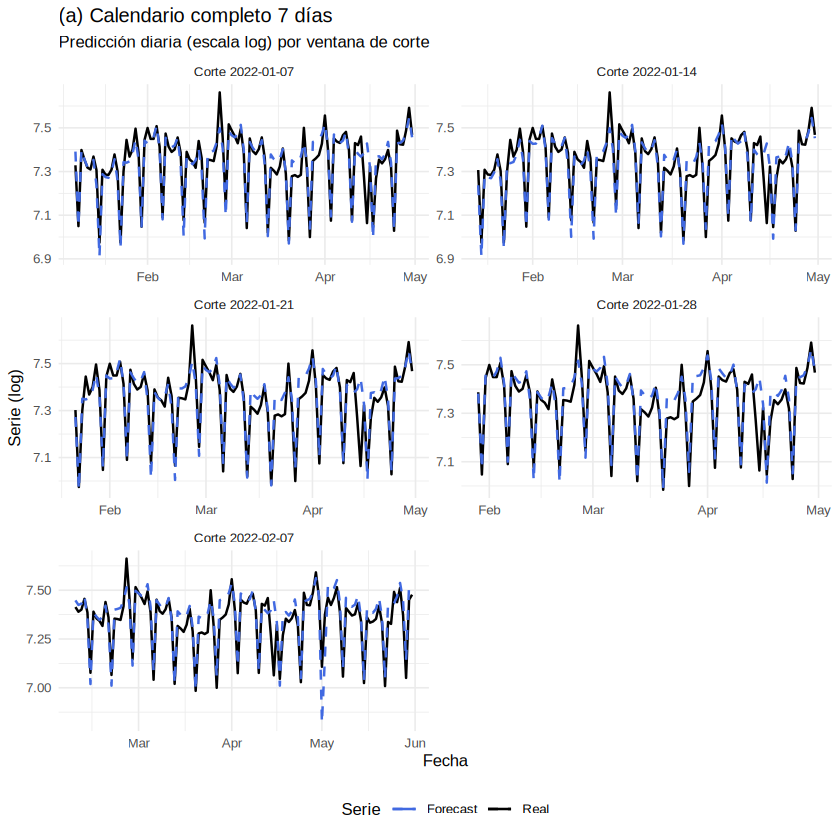

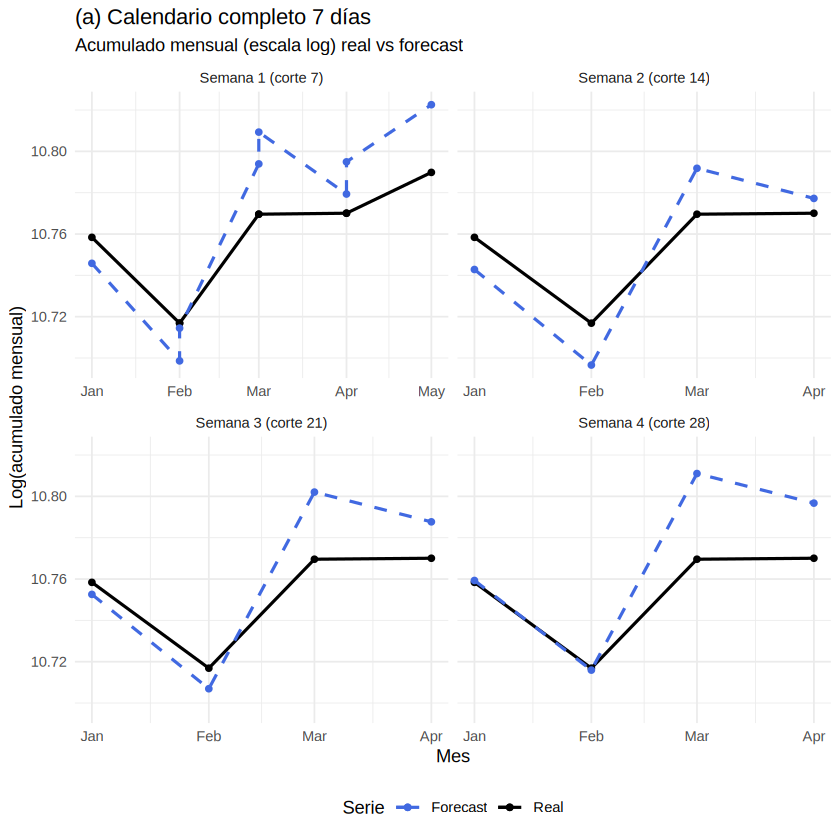

In [9]:
print(plot_daily(res_a,  "(a) Calendario completo 7 días"))
print(plot_monthly(res_a, "(a) Calendario completo 7 días"))

## (b) Calendario de negocio — 5 días, relleno = media de la semana anterior

In [10]:
res_b <- run_scenario(week_days = 5, weekend_fill = "mean")

cat("=== (b) BUSINESS 5-DÍAS (mean) — Resumen de cortes ===\n")
print(res_b$cutoff_summary[, c("cutoff_date","cutoff_day","week_no","prediction_length","train_rows","week_days","weekend_fill")])
cat("\n=== (b) SCORE MENSUAL DESAGREGADO (punto de partida x horizonte) ===\n")
score_b <- score_monthly(res_b); print(as.data.frame(score_b), digits = 3)

=== (b) BUSINESS 5-DÍAS (mean) — Resumen de cortes ===


  cutoff_date cutoff_day week_no prediction_length train_rows week_days
1  2022-01-07          5       1                80       1833         5
2  2022-01-14         10       2                75       1840         5
3  2022-01-21         15       3                70       1847         5
4  2022-01-28         20       4                65       1854         5
5  2022-02-07          5       1                81       1864         5
  weekend_fill
1         mean
2         mean
3         mean
4         mean
5         mean



=== (b) SCORE MENSUAL DESAGREGADO (punto de partida x horizonte) ===


   week_no cutoff_day period_offset      Horizonte n  ME_pp MAE_pp MedAE_pp
1        1          5             0    Nowcast (M) 2 -0.446  0.816    0.816
2        1          5             1 Forecast (M+1) 2  1.941  3.226    3.226
3        1          5             2 Forecast (M+2) 2  3.977  3.977    3.977
4        1          5             3 Forecast (M+3) 2  4.711  4.711    4.711
5        2         10             0    Nowcast (M) 1 -1.509  1.509    1.509
6        2         10             1 Forecast (M+1) 1 -1.473  1.473    1.473
7        2         10             2 Forecast (M+2) 1  3.443  3.443    3.443
8        2         10             3 Forecast (M+3) 1  2.665  2.665    2.665
9        3         15             0    Nowcast (M) 1 -0.873  0.873    0.873
10       3         15             1 Forecast (M+1) 1 -0.313  0.313    0.313
11       3         15             2 Forecast (M+2) 1  4.191  4.191    4.191
12       3         15             3 Forecast (M+3) 1  3.052  3.052    3.052
13       4  

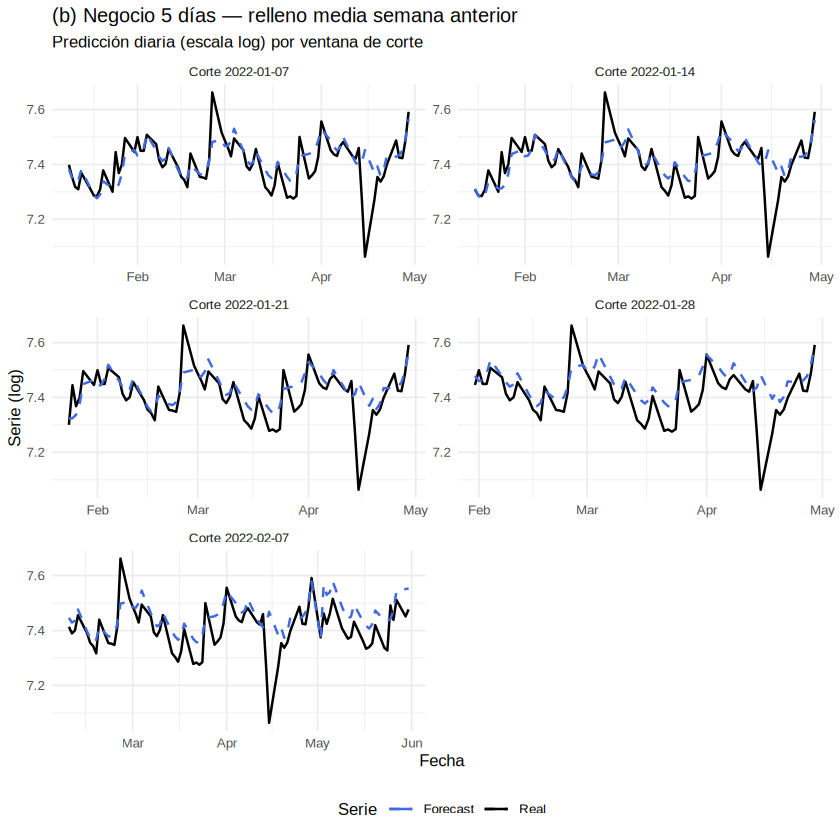

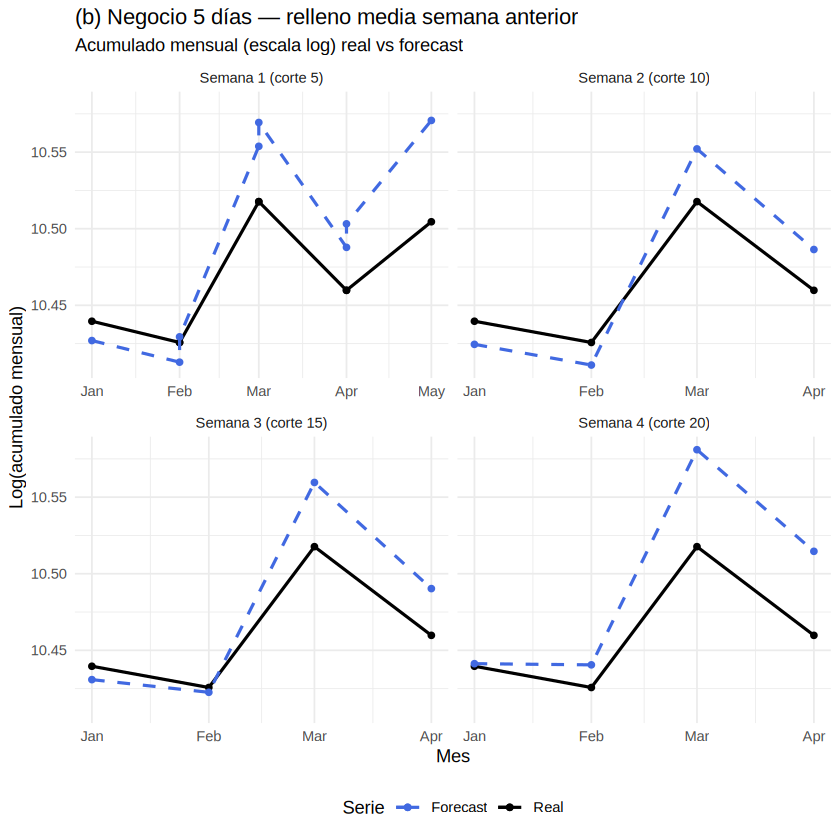

In [11]:
print(plot_daily(res_b,  "(b) Negocio 5 días — relleno media semana anterior"))
print(plot_monthly(res_b, "(b) Negocio 5 días — relleno media semana anterior"))

## (c) Calendario de negocio — 5 días, relleno = interpolación lineal

In [12]:
res_c <- run_scenario(week_days = 5, weekend_fill = "interp")

cat("=== (c) BUSINESS 5-DÍAS (interp) — Resumen de cortes ===\n")
print(res_c$cutoff_summary[, c("cutoff_date","cutoff_day","week_no","prediction_length","train_rows","week_days","weekend_fill")])
cat("\n=== (c) SCORE MENSUAL DESAGREGADO (punto de partida x horizonte) ===\n")
score_c <- score_monthly(res_c); print(as.data.frame(score_c), digits = 3)

=== (c) BUSINESS 5-DÍAS (interp) — Resumen de cortes ===


  cutoff_date cutoff_day week_no prediction_length train_rows week_days
1  2022-01-07          5       1                80       1833         5
2  2022-01-14         10       2                75       1840         5
3  2022-01-21         15       3                70       1847         5
4  2022-01-28         20       4                65       1854         5
5  2022-02-07          5       1                81       1864         5
  weekend_fill
1       interp
2       interp
3       interp
4       interp
5       interp



=== (c) SCORE MENSUAL DESAGREGADO (punto de partida x horizonte) ===


   week_no cutoff_day period_offset      Horizonte n  ME_pp MAE_pp MedAE_pp
1        1          5             0    Nowcast (M) 2 -0.318  0.318    0.318
2        1          5             1 Forecast (M+1) 2  1.151  2.653    2.653
3        1          5             2 Forecast (M+2) 2  1.624  1.624    1.624
4        1          5             3 Forecast (M+3) 2  1.187  1.726    1.726
5        2         10             0    Nowcast (M) 1 -4.592  4.592    4.592
6        2         10             1 Forecast (M+1) 1 -7.621  7.621    7.621
7        2         10             2 Forecast (M+2) 1 -3.187  3.187    3.187
8        2         10             3 Forecast (M+3) 1 -6.664  6.664    6.664
9        3         15             0    Nowcast (M) 1 -1.730  1.730    1.730
10       3         15             1 Forecast (M+1) 1 -3.700  3.700    3.700
11       3         15             2 Forecast (M+2) 1  0.701  0.701    0.701
12       3         15             3 Forecast (M+3) 1 -2.793  2.793    2.793
13       4  

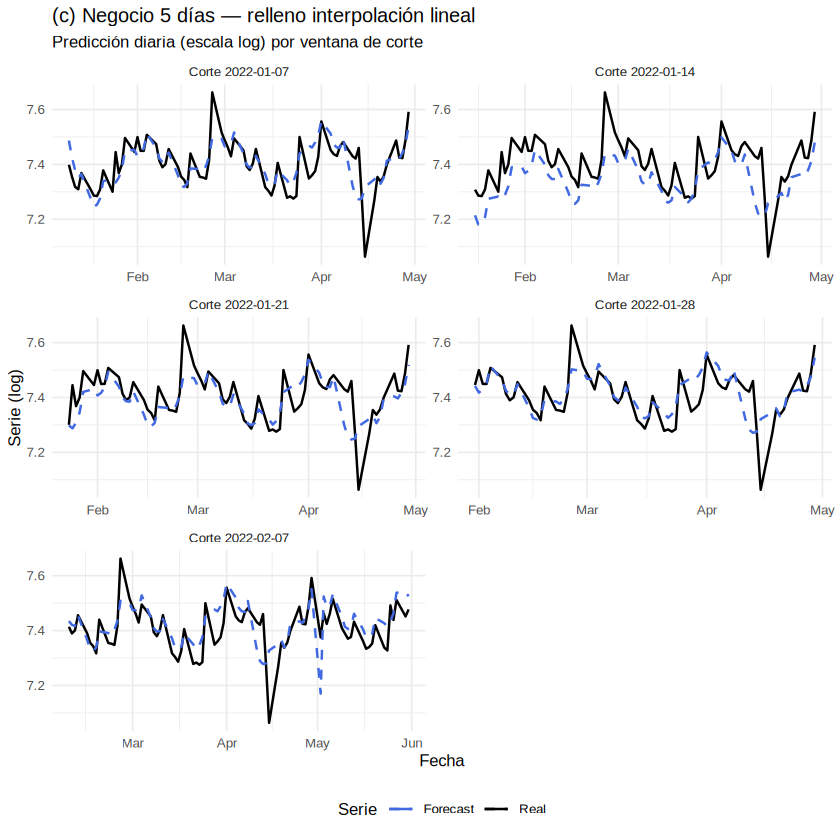

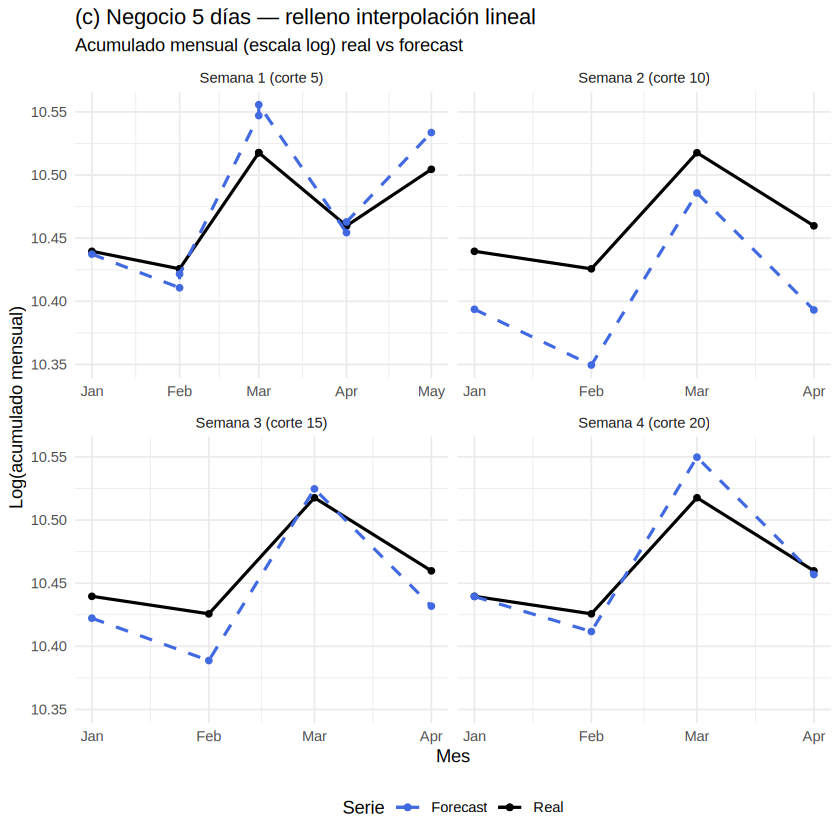

In [13]:
print(plot_daily(res_c,  "(c) Negocio 5 días — relleno interpolación lineal"))
print(plot_monthly(res_c, "(c) Negocio 5 días — relleno interpolación lineal"))

## Comparativa de los tres escenarios

MAE medio (pp) por horizonte y escenario, y gráfico comparativo.

=== MAE MEDIO (pp) POR ESCENARIO x HORIZONTE ===


                 Escenario Nowcast (M) Forecast (M+1) Forecast (M+2)
1              (a) Full 7d       0.745           1.50           3.02
2   (b) Business 5d - mean       0.842           1.62           4.48
3 (c) Business 5d - interp       1.664           3.84           2.18
  Forecast (M+3)
1           1.81
2           3.98
3           2.87


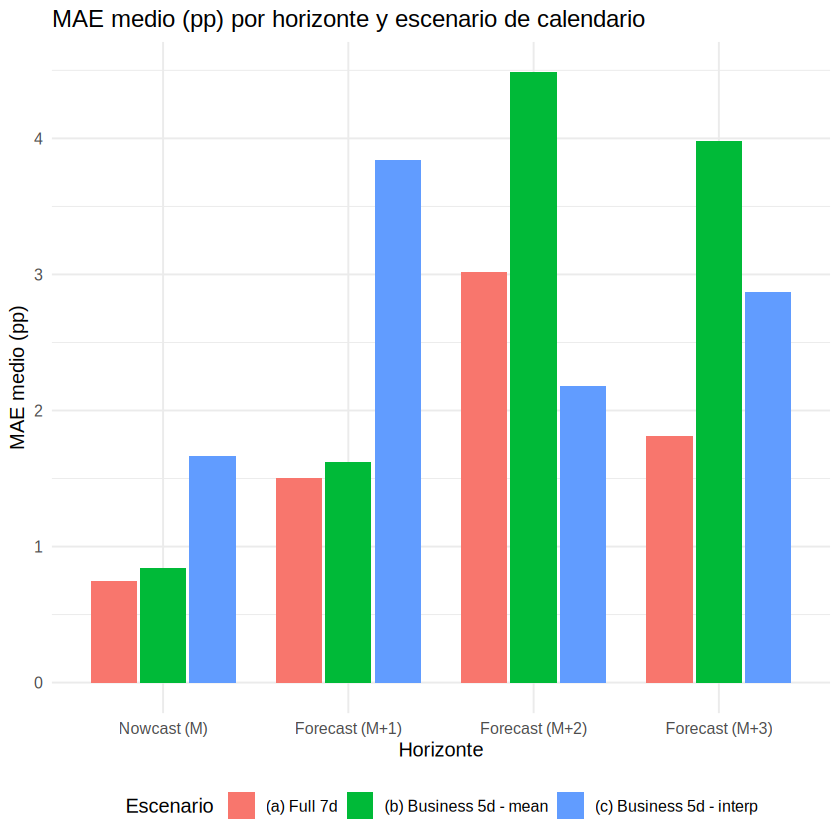

In [14]:
comp <- bind_rows(
  score_a %>% mutate(Escenario = "(a) Full 7d"),
  score_b %>% mutate(Escenario = "(b) Business 5d - mean"),
  score_c %>% mutate(Escenario = "(c) Business 5d - interp")
)

# MAE medio por horizonte y escenario
resumen <- comp %>% group_by(Escenario, Horizonte) %>%
  summarise(MAE_pp = mean(MAE_pp), MedAE_pp = mean(MedAE_pp), RMSE_pp = mean(RMSE_pp), .groups = "drop")
cat("=== MAE MEDIO (pp) POR ESCENARIO x HORIZONTE ===\n")
print(reshape2::dcast(resumen, Escenario ~ Horizonte, value.var = "MAE_pp"), digits = 3)

ggplot(resumen, aes(Horizonte, MAE_pp, fill = Escenario)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.75) +
  theme_minimal(base_size = 12) +
  labs(title = "MAE medio (pp) por horizonte y escenario de calendario",
       x = "Horizonte", y = "MAE medio (pp)", fill = "Escenario") +
  theme(legend.position = "bottom")